In [1]:
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms.v2 as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


In [2]:
train_mnist_dataset = torchvision.datasets.MNIST(root="../data/", train=True, download=True)
test_mnist_dataset = torchvision.datasets.MNIST(root="../data/", train=False, download=True)

print(f"Length of the training dataset = {len(train_mnist_dataset)}")
print(f"Length of testing dataset = {len(test_mnist_dataset)}")

Length of the training dataset = 60000
Length of testing dataset = 10000


In [3]:
class JustImageDataset(Dataset):
	def __init__(self, dataset, transform):
		self.dataset = dataset
		self.transform = transform

	def __len__(self):
		return len(self.dataset)

	def __getitem__(self, idx):
		image, _ = self.dataset[idx]
		image = self.transform(image)
		return image

In [ ]:
# initialize the transforms
train_transform = transforms.Compose([
	transforms.ToImage(),
	transforms.ToDtype(torch.uint8, scale=True),
	transforms.RandomHorizontalFlip(p=0.5),
	transforms.ToDtype(torch.float32, scale=True), # in [0, 1] range
	transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
train_dataset = JustImageDataset(train_mnist_dataset, train_transform)

In [ ]:
x = (train_dataset[0] + 1) / 2
plt.imshow(x[0].numpy(), cmap="gray")
plt.show()

In [ ]:
xn = train_dataset[0] + 0.5 * torch.randn(size=train_dataset[0].shape)
xn = (xn + 1) / 2
plt.imshow(xn[0].numpy(), cmap="gray")
plt.show()

## SECOND TRY

In [4]:
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms.v2 as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


In [5]:
from models import UNetSingleNoiseScale

device = torch.device("cuda:0")

In [6]:
train_mnist_dataset = torchvision.datasets.MNIST(root="../data/", train=True, download=True)
test_mnist_dataset = torchvision.datasets.MNIST(root="../data/", train=False, download=True)

print(f"Length of the training dataset = {len(train_mnist_dataset)}")
print(f"Length of testing dataset = {len(test_mnist_dataset)}")

Length of the training dataset = 60000
Length of testing dataset = 10000


In [8]:
# load the model
path = 'runs/mnist/v2/single-noise-scale.bin'
model = UNetSingleNoiseScale(channels=1, dim=128, norm_groups=32, dropout_prob=0.1)
model.load_state_dict(torch.load(path, map_location="cpu"))
model.to(device)

UNetSingleNoiseScale(
  (act): SiLU()
  (init_conv): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (res1): Sequential(
    (0): ResidualBlock(
      (act): SiLU()
      (b1): Sequential(
        (0): GroupNorm(32, 128, eps=1e-05, affine=True)
        (1): SiLU()
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (b2): Sequential(
        (0): GroupNorm(32, 128, eps=1e-05, affine=True)
        (1): SiLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (match_conv): Identity()
    )
    (1): ResidualBlock(
      (act): SiLU()
      (b1): Sequential(
        (0): GroupNorm(32, 128, eps=1e-05, affine=True)
        (1): SiLU()
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (b2): Sequential(
        (0): GroupNorm(32, 128, eps=1e-05, affine=True)
        (1): SiLU()
        (2): Dropout(p=0

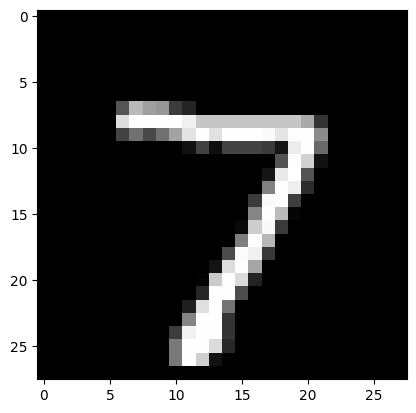

In [9]:
plt.imshow(test_mnist_dataset[0][0], cmap="gray")

In [10]:
# apply transforms
from utils import get_normalize_transform

transforms = get_normalize_transform(p=0, channels=1)

In [11]:
test_dataset = JustImageDataset(test_mnist_dataset, transforms)

In [12]:
x_batch = torch.unsqueeze(test_dataset[0], 0)
x_batch = x_batch.to(device)

print(f"shape = {x_batch.shape}")

noise = torch.randn_like(x_batch).to(device)

model.eval()
with torch.no_grad():
    x_batch_noise = x_batch + noise
    x_batch_hat = model(x_batch_noise)

print(f"out shape = {x_batch_hat.shape}")

shape = torch.Size([1, 1, 28, 28])
out shape = torch.Size([1, 1, 28, 28])


(28, 28)


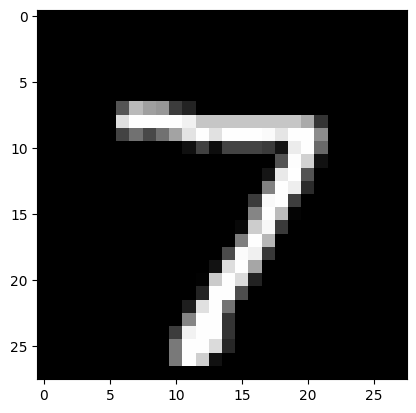

In [13]:
x = 255 * 0.5 * (x_batch.squeeze().cpu().numpy() + 1)
x = x.astype(np.uint8)
print(x.shape)
plt.imshow(x, cmap="gray")

(28, 28)


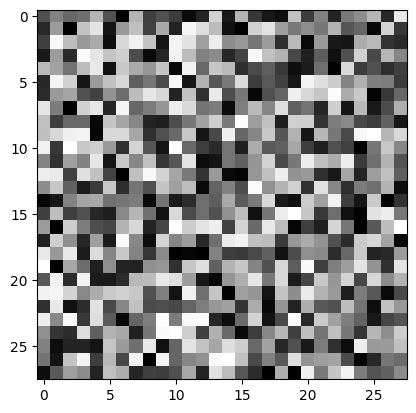

In [14]:
x = 255 * 0.5 * (x_batch_noise.squeeze().cpu().numpy() + 1)
x = x.astype(np.uint8)
print(x.shape)
plt.imshow(x, cmap="gray")

(28, 28)


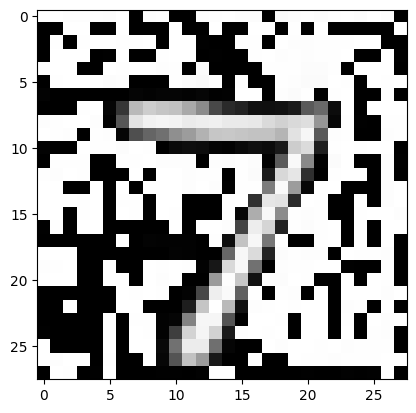

In [15]:
denoised = x_batch_noise + 1.0 * x_batch_hat
x = 255 * 0.5 * (denoised.squeeze().cpu().numpy() + 1)
x = x.astype(np.uint8)
print(x.shape)
plt.imshow(x, cmap="gray")

In this section, we will try to write the langevin sampler using the model that we trained.

Using the tweedie formulae we have E[X|Y] = y + sigma^{2} * score

We will use score in the langevin update that is yt = yt-1 + eps * score + sqrt{2 * eps} * z

where z is standard normal.

In [16]:
import math

model.eval()
noise_var = 1.0
eps = 1.0 / math.sqrt(noise_var)

trajectory = []
denoising = []

nsteps = 100

y = torch.randn((1, 1, 28, 28), device=device, dtype=torch.float32)
trajectory.append(y)

for step in range(nsteps):
	with torch.no_grad():
		# pass it to model to conditional expectation
		score = model(y)
		exgy = y + noise_var * score
		denoising.append(exgy)

	# do the langevin update
	y = y + eps * score + torch.randn_like(y) * math.sqrt(2 * eps)
	trajectory.append(y)
	# print(f"Completed step {step+1}/{nsteps}")

# run the denoising step for the last step
with torch.no_grad():
	# pass it to model to conditional expectation
	exgy = model(y)
	denoising.append(exgy)

print("Completed the langevin sampling.")

Completed the langevin sampling.


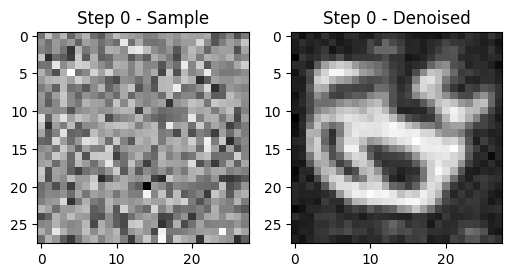

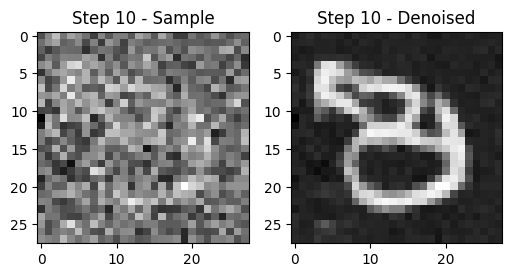

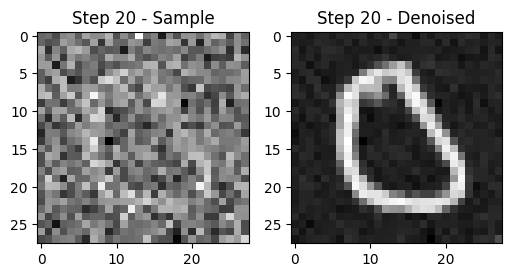

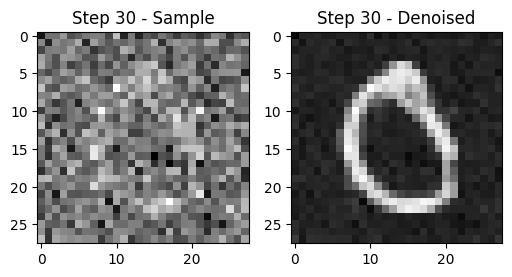

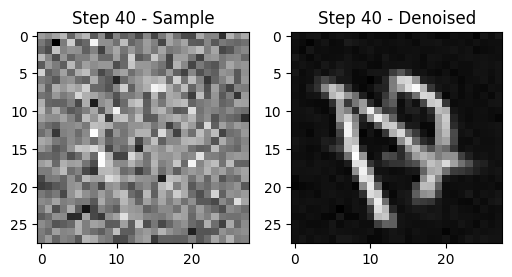

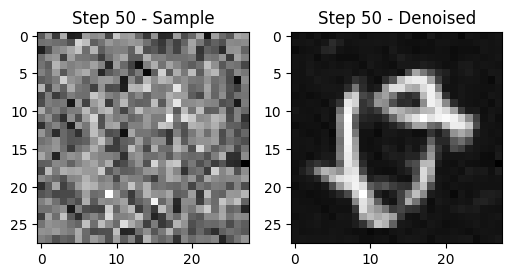

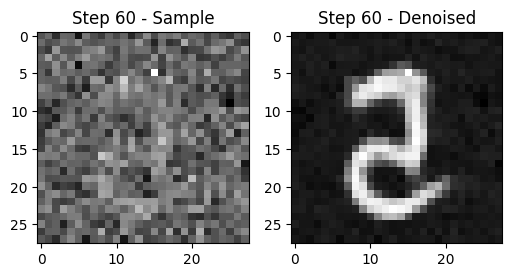

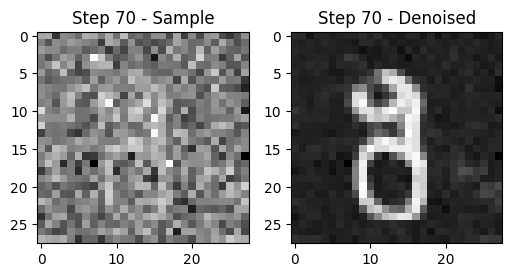

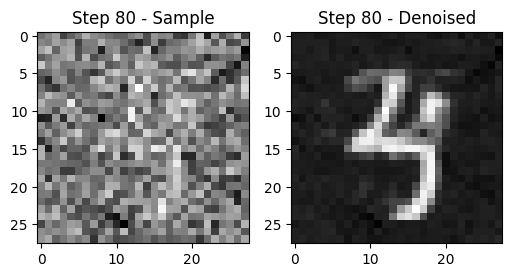

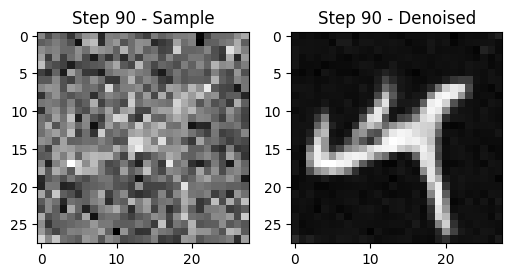

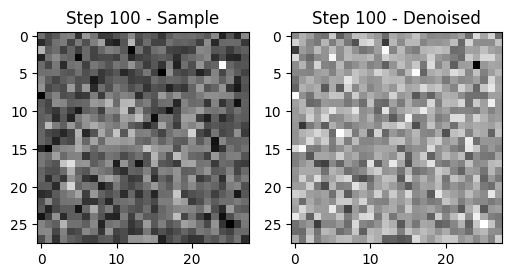

In [17]:
def helper(x):
	return 255 * 0.5 * (x.squeeze().cpu().numpy() + 1)

for step in range(0, nsteps + 1, 10):
	y = helper(trajectory[step])
	xhat = helper(denoising[step])

	plt.figure(figsize=(6, 3))
	plt.subplot(1, 2, 1)
	plt.title(f"Step {step} - Sample")
	plt.imshow(y, cmap="gray")
	plt.subplot(1, 2, 2)
	plt.title(f"Step {step} - Denoised")
	plt.imshow(xhat, cmap="gray")
	plt.show()